In [3]:
from datetime import datetime, timedelta

In [4]:
print(datetime.now())

2026-06-10 16:06:49.267424


In [7]:
datetime(year=2026, month=1, day = 31)

datetime.datetime(2026, 1, 31, 0, 0)

In [8]:
datetime.now() - timedelta(days=3)

datetime.datetime(2026, 6, 7, 16, 8, 52, 623965)

In [ ]:
import numpy as np
np.array(['2026-12-01','2026-02-01', '2026-03-01' ], dtype='datetime64')

array(['2026', '2026', '2026'], dtype='datetime64[Y]')

In [23]:
import pandas as pd 
pd.date_range(start='2026-01-01', end='2026-12-01', freq='ME')

DatetimeIndex(['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30',
               '2026-05-31', '2026-06-30', '2026-07-31', '2026-08-31',
               '2026-09-30', '2026-10-31', '2026-11-30'],
              dtype='datetime64[ns]', freq='ME')

In [28]:
import seaborn as sns
df = sns.load_dataset('flights')

In [29]:
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [36]:
df['date'] = df['year'].astype(str) + '-' + df['month'].astype(str)

In [40]:
df = df.drop(['year', 'month'] , axis=1)

In [41]:
df.head()

,passengers,date
0,112,1949-Jan
1,118,1949-Feb
2,132,1949-Mar
3,129,1949-Apr
4,121,1949-May


In [43]:
df['shift_2'] = df['passengers'].shift(2)

In [44]:
df

,passengers,date,shift_2
0,112,1949-Jan,NaN
1,118,1949-Feb,NaN
2,132,1949-Mar,112.0
3,129,1949-Apr,118.0
4,121,1949-May,132.0
...,...,...,...
139,606,1960-Aug,535.0
140,508,1960-Sep,622.0
141,461,1960-Oct,606.0
142,390,1960-Nov,508.0


In [45]:
df['upward_2'] = df['passengers'].shift(-2)

In [46]:
df

,passengers,date,shift_2,upward_2
0,112,1949-Jan,NaN,132.0
1,118,1949-Feb,NaN,129.0
2,132,1949-Mar,112.0,121.0
3,129,1949-Apr,118.0,135.0
4,121,1949-May,132.0,148.0
...,...,...,...,...
139,606,1960-Aug,535.0,461.0
140,508,1960-Sep,622.0,390.0
141,461,1960-Oct,606.0,432.0
142,390,1960-Nov,508.0,NaN


In [50]:
df_rolling = df.copy()
df_rolling['rolling_3'] = round(df_rolling['passengers'].rolling(window=3).mean())

In [51]:
df_rolling

,passengers,date,shift_2,upward_2,rolling_3
0,112,1949-Jan,NaN,132.0,NaN
1,118,1949-Feb,NaN,129.0,NaN
2,132,1949-Mar,112.0,121.0,121.0
3,129,1949-Apr,118.0,135.0,126.0
4,121,1949-May,132.0,148.0,127.0
...,...,...,...,...,...
139,606,1960-Aug,535.0,461.0,588.0
140,508,1960-Sep,622.0,390.0,579.0
141,461,1960-Oct,606.0,432.0,525.0
142,390,1960-Nov,508.0,NaN,453.0


In [49]:
(112+118+132)/3

120.66666666666667

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [2]:
pip install meteostat

Note: you may need to restart the kernel to use updated packages.


In [7]:
from meteostat import Point, Monthly
start = datetime.datetime(1970, 3, 1)
end = datetime.datetime(2022, 12, 31)
location = Point(40.416775, -3.703790)
df_madrid = Monthly(location, start, end).fetch()
df_madrid.head()


,tavg,tmin,tmax,prcp,wspd,pres,tsun
time,,,,,,,
1970-03-01,9.8,3.2,12.9,14.6,<NA>,1016.0,<NA>
1970-04-01,13.1,7.2,18.9,1.4,<NA>,1021.0,<NA>
1970-05-01,16.5,11.0,22.0,18.8,<NA>,1016.0,<NA>
1970-06-01,20.6,15.5,25.8,17.7,<NA>,1016.0,<NA>
1970-07-01,24.6,18.1,31.2,11.5,<NA>,1016.0,<NA>


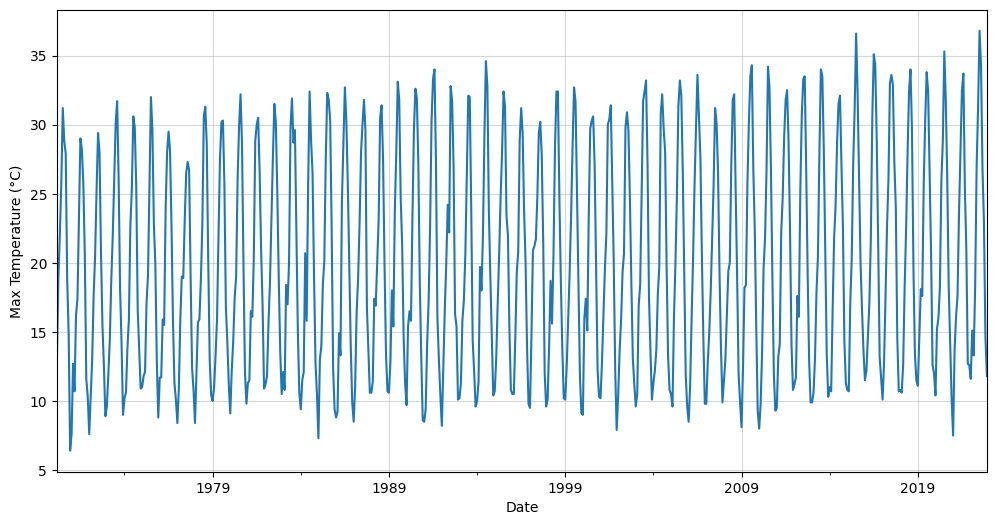

In [8]:
df_temp_max = df_madrid['tmax'].copy()
df_temp_max.plot(figsize=(12,6))
plt.grid(alpha=0.5)
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.show()

In [9]:
df_temp_max.isna().sum()

np.int64(0)

In [3]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 4.0 MB/s  0:00:02eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]
Note: you may need to restart the kernel to use updated packages.


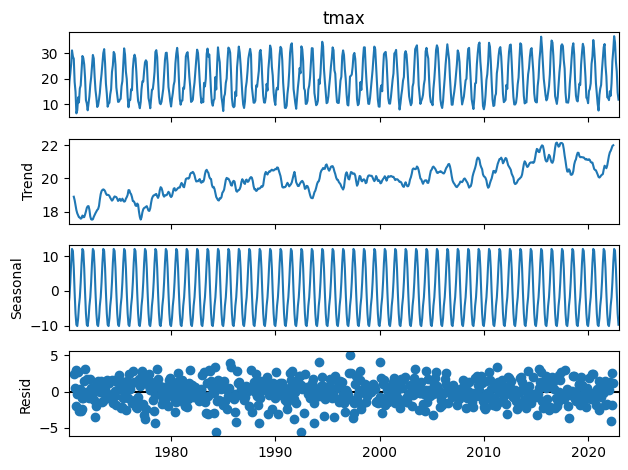

In [9]:
import statsmodels.api as sm
decomposition = sm.tsa.seasonal_decompose(df_temp_max, model='additive', period = 12)
trend = decomposition.trend
seasonality = decomposition.seasonal
residuals = decomposition.resid
decomposition.plot()
plt.show()

In [10]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_temp_max)
result

(np.float64(-2.998979284513443),
 np.float64(0.034989832272407054),
 11,
 622,
 {'1%': np.float64(-3.4409070618215996),
  '5%': np.float64(-2.8661978948030686),
  '10%': np.float64(-2.569250572471335)},
 np.float64(2520.093619879126))

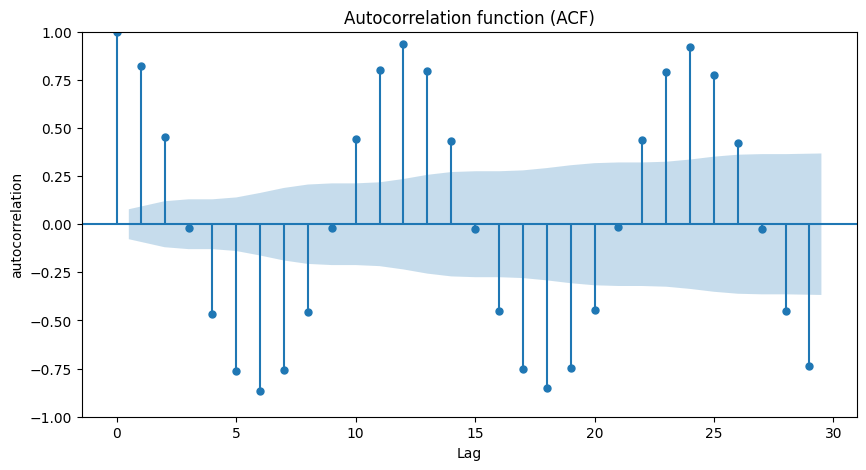

In [14]:
# p value is less than cretical values so we assume time series is stationary
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Plot acf
fig, ax = plt.subplots(figsize=(10,5))
plot_acf(df_temp_max, ax=ax)
plt.xlabel('Lag')
plt.ylabel('autocorrelation')
plt.title('Autocorrelation function (ACF)')
plt.show()

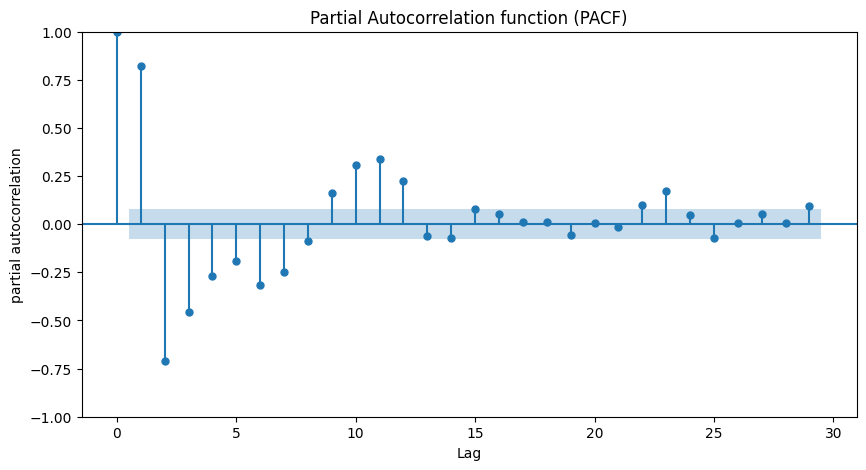

In [15]:
fig, ax = plt.subplots(figsize=(10,5))
plot_pacf(df_temp_max, ax=ax)
plt.xlabel('Lag')
plt.ylabel('partial autocorrelation')
plt.title('Partial Autocorrelation function (PACF)')
plt.show()

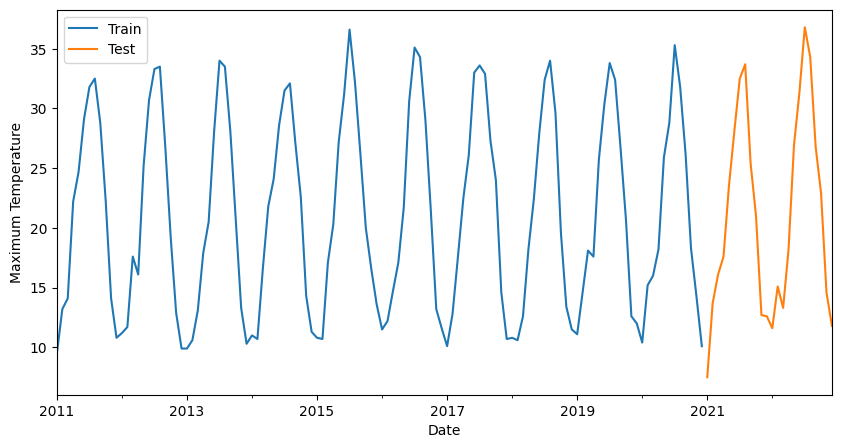

In [17]:
df_train = df_temp_max.loc[:'2020']
df_test = df_temp_max.loc['2021':]
ax = df_train[-12*10:].plot(figsize=(10,5))
df_test.plot(ax=ax)
plt.legend(['Train', 'Test'])
plt.xlabel('Date')
plt.ylabel('Maximum Temperature')
plt.show()